In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
%%capture
!pip install -q --force-reinstall "numpy==1.26.4" "albumentations==1.4.18" opencv-python-headless

In [ ]:
%%capture
%cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/DeepfakeBench
!pip install jedi
!python -m pip install -U pip setuptools wheel
!pip install -r requirements.txt
!pip install -e .

In [ ]:
%%capture
%cd "/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub"
!head -n -1 requirements.txt > requirements_no_flash.txt
!pip install -r requirements_no_flash.txt

In [ ]:
import os, glob, json

TEST_DIR = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/publictest_data"
TEST_REF = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/RDDC_References/publictest_reference/reference.txt"
STAGING  = "/content/DiffusionForensics_Recons"
os.makedirs(STAGING, exist_ok=True)

with open(TEST_REF) as f:
    test_labels = [int(l.strip()) for l in f if l.strip()]
test_images = sorted(p for p in glob.glob(os.path.join(TEST_DIR, "*.*"))
                     if os.path.splitext(p)[1].lower() in (".png",".jpg",".jpeg",".webp",".bmp",".tif",".tiff"))
assert len(test_images) == len(test_labels)
test_items = [{"path": p, "label": l} for p, l in zip(test_images, test_labels)]
with open(f"{STAGING}/test.json", "w") as f:
    json.dump(test_items, f)
print(f"✓ test.json: {len(test_items)} items")

✓ test.json: 1000 items


In [ ]:
# ── 4-model soft-voting ensemble: Effort + SPSL + TruFor + Capsule-Net ──

%matplotlib inline
import os
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

THRESHOLD = 0.5

ROOT = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/test_outputs"

EFFORT_DIR  = f"{ROOT}/effort"
SPSL_DIR    = f"{ROOT}/spsl"
TRUFOR_DIR  = f"{ROOT}/trufor"
CAPSULE_DIR = f"{ROOT}/capsule"

ENS_DIR = f"{ROOT}/ensemble_effort_spsl_trufor_capsule"
os.makedirs(ENS_DIR, exist_ok=True)


def load_preds_and_labels(model_dir, model_name):
    pred_path = f"{model_dir}/preds.npy"
    label_path = f"{model_dir}/labels.npy"

    if not os.path.exists(pred_path):
        raise FileNotFoundError(f"{model_name}: missing preds.npy at {pred_path}")

    if not os.path.exists(label_path):
        raise FileNotFoundError(f"{model_name}: missing labels.npy at {label_path}")

    preds = np.load(pred_path).astype(float)
    labels = np.load(label_path).astype(int)

    print(f"{model_name}: loaded {len(preds)} predictions from {model_dir}")

    return preds, labels


def orient_as_fake_probability(scores, labels, model_name):
    """
    Ensures each model score behaves as fake probability.
    If AUC(1-score) is better than AUC(score), the score is inverted.
    """
    auc_direct = roc_auc_score(labels, scores)
    auc_inverted = roc_auc_score(labels, 1.0 - scores)

    if auc_inverted > auc_direct:
        print(f"{model_name}: score appears reversed. Using 1 - score.")
        return 1.0 - scores, auc_inverted, "1 - score"
    else:
        print(f"{model_name}: score appears to be fake probability. Using score directly.")
        return scores, auc_direct, "score"


# ── Load all model predictions ─────────────────────────────────────────────
p_effort_raw, labels_effort = load_preds_and_labels(EFFORT_DIR, "Effort")
p_spsl_raw, labels_spsl = load_preds_and_labels(SPSL_DIR, "SPSL")
p_trufor_raw, labels_trufor = load_preds_and_labels(TRUFOR_DIR, "TruFor")
p_capsule_raw, labels_capsule = load_preds_and_labels(CAPSULE_DIR, "Capsule-Net")


# ── Check label consistency ────────────────────────────────────────────────
if not (
    np.array_equal(labels_effort, labels_spsl)
    and np.array_equal(labels_effort, labels_trufor)
    and np.array_equal(labels_effort, labels_capsule)
):
    raise RuntimeError("Labels do not match across model output folders. Check test ordering.")

labels = labels_effort


# ── Orient all scores as fake probabilities ────────────────────────────────
p_effort, auc_effort, mode_effort = orient_as_fake_probability(p_effort_raw, labels, "Effort")
p_spsl, auc_spsl, mode_spsl = orient_as_fake_probability(p_spsl_raw, labels, "SPSL")
p_trufor, auc_trufor, mode_trufor = orient_as_fake_probability(p_trufor_raw, labels, "TruFor")
p_capsule, auc_capsule, mode_capsule = orient_as_fake_probability(p_capsule_raw, labels, "Capsule-Net")


# ── Soft-voting ensemble ───────────────────────────────────────────────────
ensemble_preds = (p_effort + p_spsl + p_trufor + p_capsule) / 4.0
ensemble_labels = labels.copy()

ensemble_binary = (ensemble_preds >= THRESHOLD).astype(int)

ensemble_auc = roc_auc_score(ensemble_labels, ensemble_preds)
ensemble_f1 = f1_score(ensemble_labels, ensemble_binary)
ensemble_acc = accuracy_score(ensemble_labels, ensemble_binary)


# ── Save outputs ───────────────────────────────────────────────────────────
np.save(f"{ENS_DIR}/preds.npy", ensemble_preds)
np.save(f"{ENS_DIR}/labels.npy", ensemble_labels)

np.save(f"{ENS_DIR}/preds_effort_oriented.npy", p_effort)
np.save(f"{ENS_DIR}/preds_spsl_oriented.npy", p_spsl)
np.save(f"{ENS_DIR}/preds_trufor_oriented.npy", p_trufor)
np.save(f"{ENS_DIR}/preds_capsule_oriented.npy", p_capsule)

print("\n=== Individual Model AUCs on Public Test ===")
print(f"Effort:      {auc_effort:.4f}   ({mode_effort})")
print(f"SPSL:        {auc_spsl:.4f}   ({mode_spsl})")
print(f"TruFor:      {auc_trufor:.4f}   ({mode_trufor})")
print(f"Capsule-Net: {auc_capsule:.4f}   ({mode_capsule})")

print("\n=== 4-Model Soft-Voting Ensemble on Public Test ===")
print(f"AUC: {ensemble_auc:.4f}")
print(f"F1 : {ensemble_f1:.4f}")
print(f"Acc: {ensemble_acc:.4f}")
print(f"Saved to: {ENS_DIR}")

Effort: loaded 1000 predictions from /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/test_outputs/effort
SPSL: loaded 1000 predictions from /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/test_outputs/spsl
TruFor: loaded 1000 predictions from /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/test_outputs/trufor
Capsule-Net: loaded 1000 predictions from /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/test_outputs/capsule
Effort: score appears to be fake probability. Using score directly.
SPSL: score appears to be fake probability. Using score directly.
TruFor: score appears to be fake probability. Using score directly.
Capsule-Net: score appears to be fake probability. Using score directly.

=== Individual Model AUCs on Public Test ===
Effort:      0.7647   (score)
SPSL:        0.6431   (score)
TruFor:      0.5353   (score)
Capsule-Net: 0.5780   (score)

=== 4-Model Soft-Voting Ensemble on Public Test ===
AUC:

Checking saved 4-model ensemble outputs:
OK    /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/test_outputs/ensemble_effort_spsl_trufor_capsule/preds.npy
OK    /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/test_outputs/ensemble_effort_spsl_trufor_capsule/labels.npy
Copied component file: preds_effort_oriented.npy
Copied component file: preds_spsl_oriented.npy
Copied component file: preds_trufor_oriented.npy
Copied component file: preds_capsule_oriented.npy

Copied 4-model ensemble files into one-command format:
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/ensemble_effort_spsl_trufor_capsule/preds.npy
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/ensemble_effort_spsl_trufor_capsule/labels.npy
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/ensemble_effort_spsl_trufor_capsule/ensemble_effort_spsl_trufor_capsule_test_inference_results.json
 - /content/drive/MyDrive/Capstone_Hripsime/

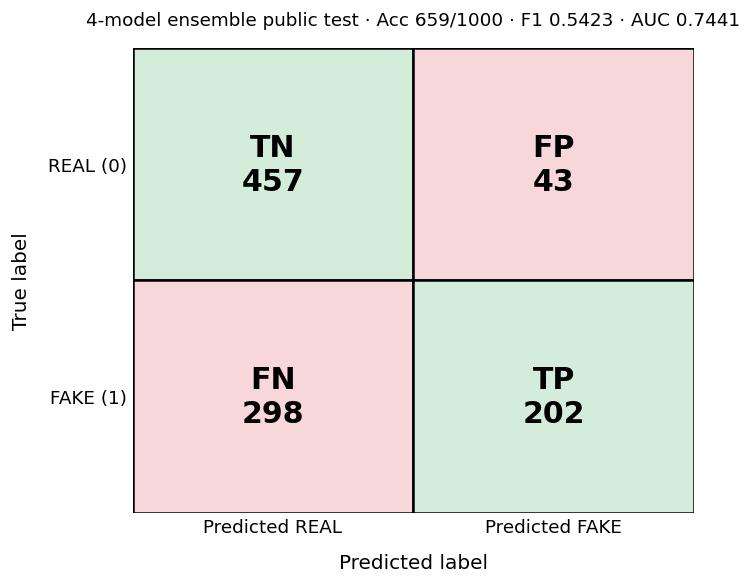

In [2]:
# ============================================================
# Copy already-saved 4-model ensemble outputs
# Effort + SPSL + TruFor + CapsuleNet
# into one-command submission format
# DOES NOT recompute ensemble
# Also saves confusion matrix figure
# ============================================================

%matplotlib inline

import json
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
)

SRC_ROOT = Path("/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/test_outputs")
SRC_ENS = SRC_ROOT / "ensemble_effort_spsl_trufor_capsule"

SUBMISSION_ROOT = Path("/content/drive/MyDrive/Capstone_Hripsime/submission")
DST_ENS = SUBMISSION_ROOT / "test_outputs" / "ensemble_effort_spsl_trufor_capsule"
DST_ENS.mkdir(parents=True, exist_ok=True)

FIG_DIR = SUBMISSION_ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

src_preds = SRC_ENS / "preds.npy"
src_labels = SRC_ENS / "labels.npy"

print("Checking saved 4-model ensemble outputs:")
for p in [src_preds, src_labels]:
    print(("OK   " if p.exists() else "MISS "), p)

if not src_preds.exists():
    raise FileNotFoundError(
        f"Missing {src_preds}. Run your 4-model ensemble-saving cell once first, "
        "then rerun this export cell."
    )

if not src_labels.exists():
    raise FileNotFoundError(
        f"Missing {src_labels}. Run your 4-model ensemble-saving cell once first, "
        "then rerun this export cell."
    )

# Copy only existing saved arrays; no recomputation
shutil.copy2(src_preds, DST_ENS / "preds.npy")
shutil.copy2(src_labels, DST_ENS / "labels.npy")

# Optionally copy oriented component outputs if they already exist
for name in [
    "preds_effort_oriented.npy",
    "preds_spsl_oriented.npy",
    "preds_trufor_oriented.npy",
    "preds_capsule_oriented.npy",
]:
    src = SRC_ENS / name
    if src.exists():
        shutil.copy2(src, DST_ENS / name)
        print("Copied component file:", name)

# Load copied files only to make metadata/results in expected format
scores = np.load(DST_ENS / "preds.npy").astype(float).reshape(-1)
labels = np.load(DST_ENS / "labels.npy").astype(int).reshape(-1)

if len(scores) != len(labels):
    raise ValueError(f"Length mismatch: preds={len(scores)}, labels={len(labels)}")

THRESHOLD = 0.5
preds = (scores >= THRESHOLD).astype(int)

precision = precision_score(labels, preds, zero_division=0)
recall = recall_score(labels, preds, zero_division=0)
f1 = f1_score(labels, preds, zero_division=0)
acc = accuracy_score(labels, preds)
auc = roc_auc_score(labels, scores)

cm = confusion_matrix(labels, preds, labels=[0, 1])
TN, FP, FN, TP = cm.ravel()

total = TP + TN + FP + FN
correct = TP + TN
wrong = FP + FN

results = []
for i, (label, score, pred) in enumerate(zip(labels, scores, preds)):
    results.append({
        "index": int(i),
        "true_label": int(label),
        "pred": int(pred),
        "score": float(score),
        "correct": bool(pred == int(label)),
    })

with open(DST_ENS / "ensemble_effort_spsl_trufor_capsule_test_inference_results.json", "w") as f:
    json.dump(results, f, indent=2)

metadata = {
    "model": "Effort + SPSL + TruFor + CapsuleNet",
    "method": "soft_voting_average",
    "threshold": THRESHOLD,
    "source_dir": str(SRC_ENS),
    "reproduction_mode": "copied_cached_ensemble_outputs_no_recompute",
    "metrics": {
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "accuracy": float(acc),
        "auc": float(auc),
    },
    "confusion_matrix": {
        "TP": int(TP),
        "TN": int(TN),
        "FP": int(FP),
        "FN": int(FN),
    },
    "num_items": int(len(labels)),
}

with open(DST_ENS / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# ============================================================
# Plot same-style confusion matrix
# ============================================================

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")

cell_labels = [["TN", "FP"], ["FN", "TP"]]
cell_values = [[TN, FP], [FN, TP]]
cell_colors = [
    ["#d4edda", "#f8d7da"],
    ["#f8d7da", "#d4edda"],
]

for i in range(2):
    for j in range(2):
        ax.add_patch(
            plt.Rectangle(
                (j, 1 - i),
                1,
                1,
                facecolor=cell_colors[i][j],
                edgecolor="black",
                linewidth=1.5,
            )
        )
        ax.text(
            j + 0.5,
            1 - i + 0.5,
            f"{cell_labels[i][j]}\n{cell_values[i][j]}",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="black",
        )

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_yticks([1.5, 0.5])

ax.set_xticklabels(["Predicted REAL", "Predicted FAKE"], fontsize=11)
ax.set_yticklabels(["REAL (0)", "FAKE (1)"], fontsize=11)

ax.set_xlabel("Predicted label", fontsize=12, labelpad=10)
ax.set_ylabel("True label", fontsize=12, labelpad=10)
ax.tick_params(length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    f"4-model ensemble public test · Acc {correct}/{total} · F1 {f1:.4f} · AUC {auc:.4f}",
    fontsize=11,
    pad=14,
)

plt.tight_layout()

fig_path = FIG_DIR / "ensemble_effort_spsl_trufor_capsule_test_confusion_matrix_reproduced.jpg"
plt.savefig(fig_path, dpi=120, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)

print("\nCopied 4-model ensemble files into one-command format:")
print(" -", DST_ENS / "preds.npy")
print(" -", DST_ENS / "labels.npy")
print(" -", DST_ENS / "ensemble_effort_spsl_trufor_capsule_test_inference_results.json")
print(" -", DST_ENS / "metadata.json")
print(" -", fig_path)

print("\nMetrics from copied saved 4-model ensemble:")
print(f"P:    {precision:.4f}")
print(f"R:    {recall:.4f}")
print(f"F1:   {f1:.4f}")
print(f"Acc:  {acc:.4f}")
print(f"AUC:  {auc:.4f}")
print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")
print(f"Correct={correct}/{total}, Wrong={wrong}/{total}")

display(Image(filename=str(fig_path)))

Ensemble score appears to be fake probability. Using score directly.
AUC — Effort:        0.7647
AUC — SPSL:          0.6431
AUC — TruFor:        0.5353
AUC — Capsule-Net:   0.5780
AUC — Ensemble:      0.7441
Score mode used:     score

Test Accuracy: 0.6590
Test F1:       0.5423
Test AUC:      0.7441
Result:        659/1000
AUC direct:    0.7441
AUC inverted:  0.2559
══════════════════════════════════════════════════
  Confusion Matrix Results
══════════════════════════════════════════════════
  TP (fake correctly detected) : 202
  TN (real correctly detected) : 457
  FP (real wrongly called fake): 43
  FN (fake wrongly called real): 298
──────────────────────────────────────────────────
  Precision(fake): 0.8245
  Recall(fake):    0.4040
  Wrong:           341/1000


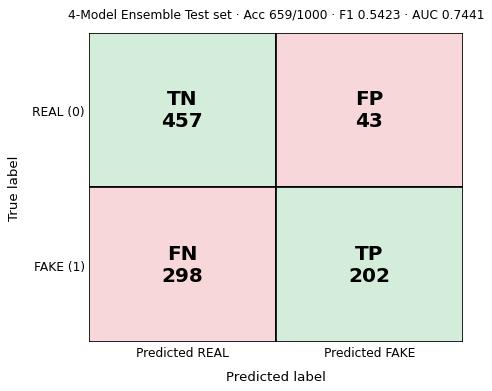


Saved plot to: /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/test_outputs/ensemble_effort_spsl_trufor_capsule/confusion_matrix.jpg


In [ ]:
# ── Confusion Matrix: 4-model ensemble ──

%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, accuracy_score
from IPython.display import Image, display

THRESHOLD = 0.5

ROOT = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/test_outputs"
ENS_DIR = f"{ROOT}/ensemble_effort_spsl_trufor_capsule"

# ── Load ensemble predictions ─────────────────────────────────────────────
preds = np.load(f"{ENS_DIR}/preds.npy")
labels = np.load(f"{ENS_DIR}/labels.npy")

if len(preds) == 0:
    raise RuntimeError("Ensemble preds file is empty.")

y_true = labels.astype(int)
y_score = preds.astype(float)

# Ensemble scores should already be fake probabilities, but check again
auc_direct = roc_auc_score(y_true, y_score)
auc_inverted = roc_auc_score(y_true, 1.0 - y_score)

if auc_inverted > auc_direct:
    print("Ensemble score appears reversed. Using 1 - score as fake probability.")
    fake_score = 1.0 - y_score
    score_mode = "1 - score"
else:
    print("Ensemble score appears to be fake probability. Using score directly.")
    fake_score = y_score
    score_mode = "score"

y_pred = (fake_score >= THRESHOLD).astype(int)

f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, fake_score)
acc = accuracy_score(y_true, y_pred)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
TN, FP, FN, TP = cm.ravel()

total = TP + TN + FP + FN
correct = TP + TN
wrong = FP + FN

precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0


# ── Per-model AUCs for context ────────────────────────────────────────────
p_effort = np.load(f"{ENS_DIR}/preds_effort_oriented.npy")
p_spsl = np.load(f"{ENS_DIR}/preds_spsl_oriented.npy")
p_trufor = np.load(f"{ENS_DIR}/preds_trufor_oriented.npy")
p_capsule = np.load(f"{ENS_DIR}/preds_capsule_oriented.npy")

print(f"AUC — Effort:        {roc_auc_score(y_true, p_effort):.4f}")
print(f"AUC — SPSL:          {roc_auc_score(y_true, p_spsl):.4f}")
print(f"AUC — TruFor:        {roc_auc_score(y_true, p_trufor):.4f}")
print(f"AUC — Capsule-Net:   {roc_auc_score(y_true, p_capsule):.4f}")
print(f"AUC — Ensemble:      {auc:.4f}")
print(f"Score mode used:     {score_mode}")
print()
print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1:       {f1:.4f}")
print(f"Test AUC:      {auc:.4f}")
print(f"Result:        {correct}/{total}")
print(f"AUC direct:    {auc_direct:.4f}")
print(f"AUC inverted:  {auc_inverted:.4f}")

print(f"{'═' * 50}")
print("  Confusion Matrix Results")
print(f"{'═' * 50}")
print(f"  TP (fake correctly detected) : {TP}")
print(f"  TN (real correctly detected) : {TN}")
print(f"  FP (real wrongly called fake): {FP}")
print(f"  FN (fake wrongly called real): {FN}")
print(f"{'─' * 50}")
print(f"  Precision(fake): {precision:.4f}")
print(f"  Recall(fake):    {recall:.4f}")
print(f"  Wrong:           {wrong}/{total}")


# ── Styled confusion matrix plot ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")

cell_labels = [["TN", "FP"], ["FN", "TP"]]
cell_values = [[TN, FP], [FN, TP]]
cell_colors = [
    ["#d4edda", "#f8d7da"],
    ["#f8d7da", "#d4edda"],
]

for i in range(2):
    for j in range(2):
        ax.add_patch(
            plt.Rectangle(
                (j, 1 - i), 1, 1,
                facecolor=cell_colors[i][j],
                edgecolor="black",
                linewidth=1.5,
            )
        )
        ax.text(
            j + 0.5,
            1 - i + 0.5,
            f"{cell_labels[i][j]}\n{cell_values[i][j]}",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="black",
        )

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_yticks([1.5, 0.5])

ax.set_xticklabels(["Predicted REAL", "Predicted FAKE"], fontsize=11)
ax.set_yticklabels(["REAL (0)", "FAKE (1)"], fontsize=11)

ax.set_xlabel("Predicted label", fontsize=12, labelpad=10)
ax.set_ylabel("True label", fontsize=12, labelpad=10)
ax.tick_params(length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    f"4-Model Ensemble Test set · "
    f"Acc {correct}/{total} · F1 {f1:.4f} · AUC {auc:.4f}",
    fontsize=11,
    pad=14,
)

plt.tight_layout()

out_path = f"{ENS_DIR}/confusion_matrix.jpg"
plt.savefig(out_path, dpi=80, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)

display(Image(out_path))
print(f"\nSaved plot to: {out_path}")

In [ ]:
import nbformat
NOTEBOOK_PATH = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Ensemble 4 Models.ipynb"

nb = nbformat.read(NOTEBOOK_PATH, as_version=4)

if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

nbformat.write(nb, NOTEBOOK_PATH)

In [ ]:
!pip install nbconvert -q

NOTEBOOK_PATH = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Ensemble 4 Models.ipynb"
OUTPUT_DIR    = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/HTML Notebooks"

!jupyter nbconvert \
    --to html \
    --embed-images \
    --output-dir "{OUTPUT_DIR}" \
    "{NOTEBOOK_PATH}"

print("Done — check your Drive for the .html file")

[NbConvertApp] Converting notebook /content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Ensemble 4 Models.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 364577 bytes to /content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/HTML Notebooks/Ensemble 4 Models.html
Done — check your Drive for the .html file
